# 02 · Metrics & Data Prep — Evaluation, Imbalance, Scaling, Missingness, Categoricals 🔴

> 📖 **Website:** [4-Hour Study Plan](http://localhost:5173/#study-plan) · Hour 2 · 60 min

In this notebook, we move from conceptual definitions to live data transformations and evaluation metrics:
1. Implement the confusion matrix metrics from scratch with pure NumPy.
2. Reproduce the website's **Threshold Lab**, sweep cost matrices, and calculate dollar savings.
3. Generate the canonical **ROC-AUC vs PR-AUC sweep under severe class imbalance**.
4. Evaluate calibration curves (reliability diagrams) and Brier scores.
5. Prove the median/mean optimality of MAE/MSE and produce a negative $R^2$.
6. Check seeded tree prediction invariance under standardization with an exact NumPy assertion.
7. Recover MNAR missing signal with missingness indicators and compare categorical encodings.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
import mlprep
from mlprep.data import make_churn_panel, make_scored_population
from mlprep.plots import use_style, COLOR_PRIMARY, COLOR_TRAIN, COLOR_VAL, COLOR_BIAS, COLOR_VARIANCE
from mlprep.checks import check_2_1, check_2_2

use_style()
SEED = 7
print(f"Environment initialized · Seed: {SEED}")


Environment initialized · Seed: 7


---
## 2.1 Confusion Matrix & Core Metrics From Scratch 🔴 (8 min)
> 📖 **Website:** [Model Evaluation Metrics](http://localhost:5173/#metrics)

**The question:** Can you implement Precision, Recall, Specificity, and F1 from scratch and verify they match scikit-learn to machine precision?

**What you'll see:** Pure NumPy metric implementations, verified against scikit-learn, plus a labelled formatted confusion matrix.

In [2]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# 1. Pure NumPy implementations from first principles
def calc_precision(tp, fp, fn, tn):
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def calc_recall(tp, fp, fn, tn):
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def calc_specificity(tp, fp, fn, tn):
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

def calc_f1(tp, fp, fn, tn):
    p = calc_precision(tp, fp, fn, tn)
    r = calc_recall(tp, fp, fn, tn)
    return (2 * p * r) / (p + r) if (p + r) > 0 else 0.0

# Synthetic binary predictions
y_true = np.array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1])
y_pred = np.array([1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1])

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Assert exact equivalence with sklearn
assert np.isclose(calc_precision(tp, fp, fn, tn), precision_score(y_true, y_pred)), "Precision mismatch"
assert np.isclose(calc_recall(tp, fp, fn, tn), recall_score(y_true, y_pred)), "Recall mismatch"
assert np.isclose(calc_f1(tp, fp, fn, tn), f1_score(y_true, y_pred)), "F1 mismatch"

# Pretty-print formatted confusion matrix
cm_df = pd.DataFrame(
    [[f"TP = {tp}", f"FN = {fn}"], [f"FP = {fp}", f"TN = {tn}"]],
    index=["Actual Positive", "Actual Negative"],
    columns=["Predicted Positive", "Predicted Negative"]
)
print("Labelled Confusion Matrix:")
print(cm_df)
print(f"\nPrecision  : {calc_precision(tp, fp, fn, tn):.3f} (Of all flagged alerts, how many were real?)")
print(f"Recall (TPR): {calc_recall(tp, fp, fn, tn):.3f} (Of all real cases, how many did we catch?)")
print(f"Specificity : {calc_specificity(tp, fp, fn, tn):.3f} (Of all clean users, how many did we leave alone?)")
print(f"F1 Score    : {calc_f1(tp, fp, fn, tn):.3f} (Harmonic mean penalizing extreme imbalances)")


Labelled Confusion Matrix:
                Predicted Positive Predicted Negative
Actual Positive             TP = 6             FN = 2
Actual Negative             FP = 2            TN = 10

Precision  : 0.750 (Of all flagged alerts, how many were real?)
Recall (TPR): 0.750 (Of all real cases, how many did we catch?)
Specificity : 0.833 (Of all clean users, how many did we leave alone?)
F1 Score    : 0.750 (Harmonic mean penalizing extreme imbalances)


### 📝 Exercise 2.1: Confusion Matrix Verification
Verify all 4 metrics against `check_2_1`.

In [3]:
# ── Exercise 2.1 ────────────────────────────────────────────────
check_2_1(calc_precision, calc_recall, calc_specificity, calc_f1)


✅ Correct! Precision (0.667), Recall (0.667), Specificity (0.778), and F1 (0.667) match scikit-learn exactly.


> 🎤 **In an interview:** "I never evaluate classifiers by accuracy when the positive rate is rare. I define the trade-off in business terms: Precision is the analyst queue purity; Recall is fraud catch rate; F1 balances them with a harmonic mean that punishes models ignoring the minority class." 

---
## 2.2 Thresholds & Cost Matrix Optimization 🔴 (12 min)
> 📖 **Website:** [Model Evaluation Metrics](http://localhost:5173/#metrics)

**The question:** The default classification threshold is $\tau = 0.5$. If a False Positive costs $\$8$ and a False Negative costs $\$400$, how much money is wasted by sticking with 0.5?

**What you'll see:** We reproduce the website's **Threshold Lab** with `make_scored_population()` (1,000 cases, 3% positive, ROC-AUC ≈ 0.94, PR-AUC ≈ 0.42) and find the cost-optimal decision threshold.

Threshold Lab ranking check: ROC-AUC=0.937, PR-AUC=0.422


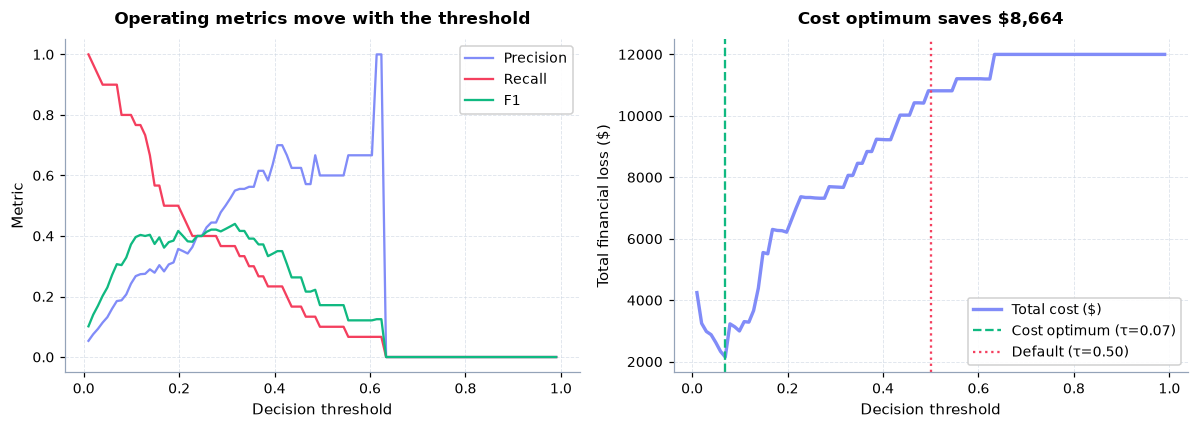

Default 0.50 Threshold Cost: $10,816.00 (TP=3, FP=2, FN=27, TN=968)
Optimal 0.07 Threshold Cost: $2,152.00 (TP=27, FP=119, FN=3, TN=851)

Financial Saving: $8,664.00 (80.1%) purely by tuning the threshold with ZERO retraining cost!
Precision@100: 24.0% (24 positives in a fixed review queue of 100)
In production, select the threshold on validation data and report its cost once on untouched test data.


In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score

df_pop = make_scored_population(n=1000, positive_rate=0.03, seed=20260822)
y_true_pop = df_pop["y_true"].values
scores_pop = df_pop["score"].values
print(f"Threshold Lab ranking check: ROC-AUC={roc_auc_score(y_true_pop, scores_pop):.3f}, PR-AUC={average_precision_score(y_true_pop, scores_pop):.3f}")

COST_FP = 8.0     # Cost of manual review or customer friction ($8)
COST_FN = 400.0   # Cost of missed fraud or lost churner ($400)

thresholds = np.linspace(0.01, 0.99, 100)
expected_costs = []
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds = (scores_pop >= t).astype(int)
    cm_t = confusion_matrix(y_true_pop, preds)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    total_cost = fp_t * COST_FP + fn_t * COST_FN
    expected_costs.append(total_cost)
    precision_t = tp_t / (tp_t + fp_t) if tp_t + fp_t else 0.0
    recall_t = tp_t / (tp_t + fn_t) if tp_t + fn_t else 0.0
    precisions.append(precision_t)
    recalls.append(recall_t)
    f1s.append(2 * precision_t * recall_t / (precision_t + recall_t) if precision_t + recall_t else 0.0)

best_idx = np.argmin(expected_costs)
best_threshold = thresholds[best_idx]
min_cost = expected_costs[best_idx]
preds_best = (scores_pop >= best_threshold).astype(int)
tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_true_pop, preds_best).ravel()

# Cost at default 0.5
preds_default = (scores_pop >= 0.5).astype(int)
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_true_pop, preds_default).ravel()
cost_default = fp_d * COST_FP + fn_d * COST_FN
savings = cost_default - min_cost

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(thresholds, precisions, label="Precision", color=COLOR_PRIMARY)
ax1.plot(thresholds, recalls, label="Recall", color=COLOR_VAL)
ax1.plot(thresholds, f1s, label="F1", color=COLOR_TRAIN)
ax1.set(title="Operating metrics move with the threshold", xlabel="Decision threshold", ylabel="Metric")
ax1.legend()
ax2.plot(thresholds, expected_costs, color=COLOR_PRIMARY, lw=2.2, label="Total cost ($)")
ax2.axvline(best_threshold, color=COLOR_TRAIN, linestyle="--", label=f"Cost optimum (τ={best_threshold:.2f})")
ax2.axvline(0.5, color=COLOR_VAL, linestyle=":", label="Default (τ=0.50)")
ax2.set(title=f"Cost optimum saves ${savings:,.0f}", xlabel="Decision threshold", ylabel="Total financial loss ($)")
ax2.legend()
plt.tight_layout()
plt.show()

print(f"Default 0.50 Threshold Cost: ${cost_default:,.2f} (TP={tp_d}, FP={fp_d}, FN={fn_d}, TN={tn_d})")
print(f"Optimal {best_threshold:.2f} Threshold Cost: ${min_cost:,.2f} (TP={tp_b}, FP={fp_b}, FN={fn_b}, TN={tn_b})")
print(f"\nFinancial Saving: ${savings:,.2f} ({savings/cost_default:.1%}) purely by tuning the threshold with ZERO retraining cost!")

k = 100
top_k = np.argsort(scores_pop)[-k:]
print(f"Precision@{k}: {y_true_pop[top_k].mean():.1%} ({y_true_pop[top_k].sum()} positives in a fixed review queue of {k})")
print("In production, select the threshold on validation data and report its cost once on untouched test data.")


### 📝 Exercise 2.2: Finding Cost-Optimal Threshold
Implement `find_best_threshold(y_true, y_scores, cost_fp, cost_fn)`.

In [5]:
# ── Exercise 2.2 ────────────────────────────────────────────────
def find_best_threshold(y_true, y_scores, cost_fp: float, cost_fn: float):
    # YOUR CODE HERE:
    # Return (best_threshold, min_cost)
    pass

# Run verification check:
# check_2_2(find_best_threshold)


<details>
<summary>💡 Solution</summary>

```python
def find_best_threshold(y_true, y_scores, cost_fp: float, cost_fn: float):
    thresholds = np.linspace(0.01, 0.99, 100)
    best_t = 0.5
    min_cost = float("inf")
    
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        cm = confusion_matrix(y_true, preds)
        tn, fp, fn, tp = cm.ravel()
        cost = fp * cost_fp + fn * cost_fn
        if cost < min_cost:
            min_cost = cost
            best_t = t
    return best_t, min_cost

check_2_2(find_best_threshold)
```
</details>

> 🎤 **In an interview:** "A score is not a decision. I choose the operating threshold on validation data from explicit error costs or queue capacity, then evaluate that frozen policy once on the test set." 

---
## 2.3 ROC-AUC vs PR-AUC Under Severe Imbalance 🔴 (10 min)
> 📖 **Website:** [Model Evaluation Metrics](http://localhost:5173/#metrics)

**The question:** Why do senior ML engineers insist on Precision–Recall AUC over ROC-AUC on imbalanced datasets?

**What you'll see:** We keep the class-conditional score distributions fixed, vary prevalence from 50% down to 0.5%, and track both metrics. ROC-AUC is prevalence-invariant in expectation, while PR-AUC changes because precision depends directly on the base rate.

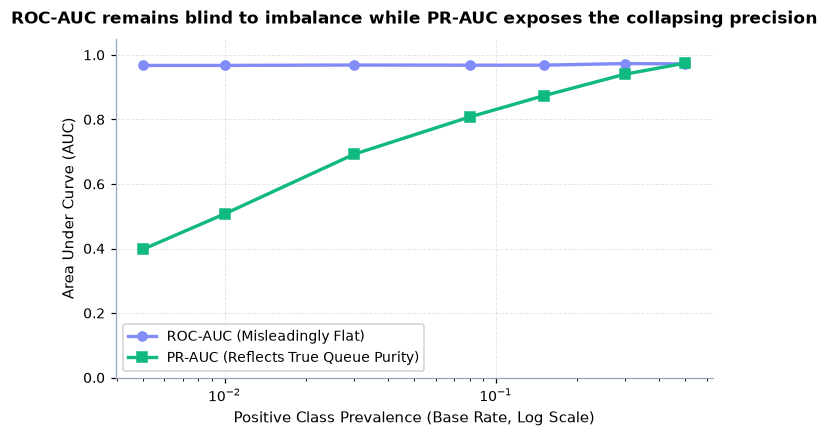

At 50% Positives : ROC-AUC = 0.972 | PR-AUC = 0.975
At 0.5% Positives: ROC-AUC = 0.967 | PR-AUC = 0.398  <-- Gap: 0.570!

Reason: ROC-AUC asks how often a random positive outranks a random negative, so prevalence is absent from its definition.
Precision includes false positives relative to predicted positives, so its achievable baseline equals the positive prevalence.


In [6]:
from sklearn.metrics import roc_auc_score, average_precision_score

base_rates = [0.50, 0.30, 0.15, 0.08, 0.03, 0.01, 0.005]
roc_aucs = []
pr_aucs = []

rng = np.random.RandomState(SEED)
n_pos = 100
pos_scores = rng.beta(a=5, b=2, size=n_pos)  # strong scores for positives

for br in base_rates:
    n_neg = int(round(n_pos * (1 - br) / br))
    neg_scores = rng.beta(a=2, b=5, size=n_neg)  # lower scores for negatives
    
    y = np.array([1] * n_pos + [0] * n_neg)
    scores = np.concatenate([pos_scores, neg_scores])
    
    roc_aucs.append(roc_auc_score(y, scores))
    pr_aucs.append(average_precision_score(y, scores))

plt.figure(figsize=(7, 4))
plt.plot(base_rates, roc_aucs, "o-", color=COLOR_PRIMARY, label="ROC-AUC (Misleadingly Flat)", lw=2.2)
plt.plot(base_rates, pr_aucs, "s-", color=COLOR_TRAIN, label="PR-AUC (Reflects True Queue Purity)", lw=2.2)
plt.xscale("log")
plt.title("ROC-AUC remains blind to imbalance while PR-AUC exposes the collapsing precision")
plt.xlabel("Positive Class Prevalence (Base Rate, Log Scale)")
plt.ylabel("Area Under Curve (AUC)")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

print(f"At 50% Positives : ROC-AUC = {roc_aucs[0]:.3f} | PR-AUC = {pr_aucs[0]:.3f}")
print(f"At 0.5% Positives: ROC-AUC = {roc_aucs[-1]:.3f} | PR-AUC = {pr_aucs[-1]:.3f}  <-- Gap: {roc_aucs[-1] - pr_aucs[-1]:.3f}!")
print("\nReason: ROC-AUC asks how often a random positive outranks a random negative, so prevalence is absent from its definition.")
print("Precision includes false positives relative to predicted positives, so its achievable baseline equals the positive prevalence.")


> 🎤 **In an interview:** "ROC-AUC measures ranking independent of prevalence. For a rare-positive alert queue I also report the precision-recall curve, its prevalence baseline, and precision at the actual review capacity." 

---
## 2.4 Model Calibration & Brier Score 🟠 (8 min)
> 📖 **Website:** [Model Evaluation Metrics](http://localhost:5173/#metrics)

**The question:** If Model A has a higher ROC-AUC than Model B, does it necessarily produce more trustworthy predicted probabilities?

**What you'll see:** We compare ranking and calibration, then show that class weighting can leave ROC-AUC similar while distorting probabilities. `CalibratedClassifierCV` repairs the probability scale using predictions from held-out folds.

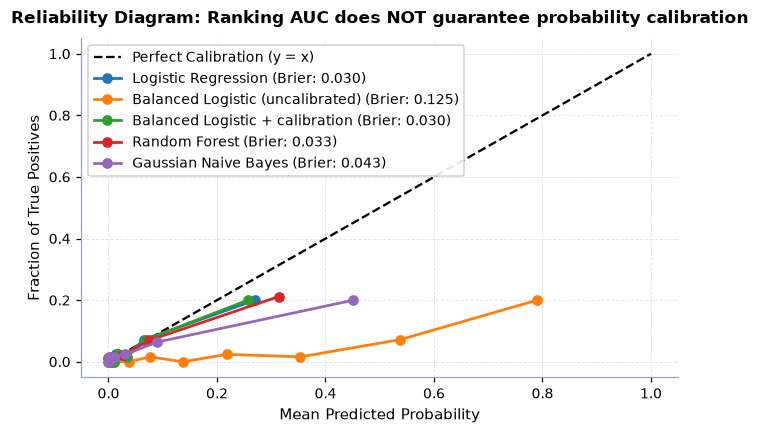

,ROC-AUC (Ranking),Brier Score (Calibration MSE),AUC rank,Brier rank
Model,,,,
Balanced Logistic + calibration,0.879,0.0302,2,1
Logistic Regression,0.879,0.0303,2,2
Random Forest,0.826,0.0330,5,3
Gaussian Naive Bayes,0.863,0.0426,4,4
Balanced Logistic (uncalibrated),0.879,0.1250,2,5


In [7]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss

df = make_churn_panel(n_users=3000, snapshots_per_user=1, seed=SEED)
X = df[["tenure_days", "monthly_spend", "logins_30d"]]
y = df["churned"]

models = {
    "Logistic Regression": LogisticRegression(random_state=SEED),
    "Balanced Logistic (uncalibrated)": LogisticRegression(class_weight="balanced", random_state=SEED),
    "Balanced Logistic + calibration": CalibratedClassifierCV(
        LogisticRegression(class_weight="balanced", random_state=SEED), method="sigmoid", cv=5
    ),
    "Random Forest": RandomForestClassifier(random_state=SEED, n_estimators=50),
    "Gaussian Naive Bayes": GaussianNB(),
}

plt.figure(figsize=(7, 4))
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration (y = x)")

calib_summary = []
for name, m in models.items():
    m.fit(X[:2000], y[:2000])
    probs = m.predict_proba(X[2000:])[:, 1]
    prob_true, prob_pred = calibration_curve(y[2000:], probs, n_bins=8, strategy="quantile")
    
    auc = roc_auc_score(y[2000:], probs)
    brier = brier_score_loss(y[2000:], probs)
    calib_summary.append({"Model": name, "ROC-AUC (Ranking)": np.round(auc, 3), "Brier Score (Calibration MSE)": np.round(brier, 4)})
    
    plt.plot(prob_pred, prob_true, "o-", label=f"{name} (Brier: {brier:.3f})", lw=1.8)

plt.title("Reliability Diagram: Ranking AUC does NOT guarantee probability calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of True Positives")
plt.legend()
plt.show()

calib_df = pd.DataFrame(calib_summary).set_index("Model")
calib_df["AUC rank"] = calib_df["ROC-AUC (Ranking)"].rank(ascending=False).astype(int)
calib_df["Brier rank"] = calib_df["Brier Score (Calibration MSE)"].rank().astype(int)
calib_df.sort_values("Brier Score (Calibration MSE)")


> 🎤 **In an interview:** "Ranking use cases (search ordering, ad CTR auction bid sorting) care about ROC-AUC. Expected-value use cases (credit default loss provisioning, insurance underwriting) care about calibration, measured by Brier score or expected calibration error (ECE)." 

---
## 2.5 Regression Metrics & Negative $R^2$ 🔴 (8 min)
> 📖 **Website:** [Model Evaluation Metrics](http://localhost:5173/#metrics)

**The question:** Why does MAE find the conditional median while MSE finds the conditional mean, and how can an out-of-sample $R^2$ score become negative?

**What you'll see:** 
1. Brute-force constant optimization proving the median minimizes MAE and the mean minimizes MSE.
2. Generating a negative test $R^2$ on an overfitted polynomial.

In [8]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# 1. Optimal constant predictor proof
sample = np.array([10, 12, 14, 15, 18, 20, 100])  # Skewed sample with outlier
c_candidates = np.linspace(5, 45, 200)

mae_losses = [np.mean(np.abs(sample - c)) for c in c_candidates]
mse_losses = [np.mean((sample - c) ** 2) for c in c_candidates]

opt_mae_c = c_candidates[np.argmin(mae_losses)]
opt_mse_c = c_candidates[np.argmin(mse_losses)]

print(f"Sample: {sample.tolist()}")
print(f"Empirical Sample Median = {np.median(sample):.2f} | MAE Loss Minimizer = {opt_mae_c:.2f}")
print(f"Empirical Sample Mean   = {np.mean(sample):.2f} | MSE Loss Minimizer = {opt_mse_c:.2f}")

# 2. Negative R2 Demo
rng_reg = np.random.RandomState(SEED)
X_tr_toy = np.linspace(0, 1, 10).reshape(-1, 1)
y_tr_toy = 3 * X_tr_toy.ravel() + rng_reg.normal(0, 0.1, 10)
X_te_toy = np.linspace(1.1, 2.0, 10).reshape(-1, 1)
y_te_toy = 3 * X_te_toy.ravel() + rng_reg.normal(0, 0.1, 10)

poly_feat = PolynomialFeatures(degree=9)
X_tr_poly_toy = poly_feat.fit_transform(X_tr_toy)
X_te_poly_toy = poly_feat.transform(X_te_toy)

bad_poly = Ridge(alpha=0).fit(X_tr_poly_toy, y_tr_toy)
bad_preds = bad_poly.predict(X_te_poly_toy)
neg_r2 = r2_score(y_te_toy, bad_preds)


print(f"\nOverfitted Polynomial Test R² = {neg_r2:.2f}")
print("Interpretation: test R² is negative when predictions are worse than the constant test-set mean baseline used by the metric.")

# 3. MAE vs RMSE sensitivity to a few extreme residuals
clean_errors = rng_reg.normal(0, 1, 200)
contaminated_errors = clean_errors.copy()
contaminated_errors[:3] = [12, -15, 18]
for label, errors in [("Clean", clean_errors), ("Three outliers", contaminated_errors)]:
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))
    print(f"{label:<14}: MAE={mae:.2f} | RMSE={rmse:.2f} | RMSE/MAE={rmse/mae:.2f}")


Sample: [10, 12, 14, 15, 18, 20, 100]
Empirical Sample Median = 15.00 | MAE Loss Minimizer = 15.05
Empirical Sample Mean   = 27.00 | MSE Loss Minimizer = 26.91

Overfitted Polynomial Test R² = -1959887761.23
Interpretation: test R² is negative when predictions are worse than the constant test-set mean baseline used by the metric.
Clean         : MAE=0.80 | RMSE=0.99 | RMSE/MAE=1.23
Three outliers: MAE=1.02 | RMSE=2.10 | RMSE/MAE=2.07


> 🎤 **In an interview:** "MAE is robust to outliers because its derivative is constant ($\pm 1$), whereas MSE heavily penalizes extreme residuals. Minimizing MAE estimates the conditional median; minimizing MSE estimates the conditional mean." 

---
## 2.6 Feature Engineering: Expose the Interaction 🟠 (6 min)
> 📖 **Website:** [Feature Engineering](http://localhost:5173/#feature-engineering)

**The question:** If risk depends on two features jointly, can a linear model recover the pattern without being given an interaction?

**What you'll see:** The churn generator plants a spend×short-tenure interaction. We expose that term explicitly to logistic regression and compare it with a tree model that can learn threshold interactions directly.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import log_loss

df_fe = make_churn_panel(n_users=20000, snapshots_per_user=1, seed=SEED)
base_cols = ["tenure_days", "monthly_spend"]
X_fe = df_fe[base_cols].copy()
X_fe["spend_x_short_tenure"] = (X_fe["monthly_spend"] / 55.0) * np.exp(-X_fe["tenure_days"] / 130.0)
y_fe = df_fe["churned"]
Xf_train, Xf_test, yf_train, yf_test = train_test_split(X_fe, y_fe, test_size=0.3, stratify=y_fe, random_state=SEED)

def logistic_metrics(columns):
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1500))])
    model.fit(Xf_train[columns], yf_train)
    probs = model.predict_proba(Xf_test[columns])[:, 1]
    return roc_auc_score(yf_test, probs), average_precision_score(yf_test, probs), log_loss(yf_test, probs)

base_metrics = logistic_metrics(base_cols)
interaction_metrics = logistic_metrics(base_cols + ["spend_x_short_tenure"])
tree_fe = HistGradientBoostingClassifier(random_state=SEED).fit(Xf_train[base_cols], yf_train)
tree_probs = tree_fe.predict_proba(Xf_test[base_cols])[:, 1]
print(f"Linear, raw features         : ROC-AUC={base_metrics[0]:.3f} | PR-AUC={base_metrics[1]:.3f} | Log Loss={base_metrics[2]:.3f}")
print(f"Linear, + planted interaction: ROC-AUC={interaction_metrics[0]:.3f} | PR-AUC={interaction_metrics[1]:.3f} | Log Loss={interaction_metrics[2]:.3f}")
print(f"Incremental PR-AUC from feature engineering: {interaction_metrics[1]-base_metrics[1]:+.3f}")
print(f"Tree, raw features           : ROC-AUC={roc_auc_score(yf_test, tree_probs):.3f} | PR-AUC={average_precision_score(yf_test, tree_probs):.3f}")


Linear, raw features         : ROC-AUC=0.860 | PR-AUC=0.362 | Log Loss=0.150
Linear, + planted interaction: ROC-AUC=0.861 | PR-AUC=0.389 | Log Loss=0.146
Incremental PR-AUC from feature engineering: +0.027
Tree, raw features           : ROC-AUC=0.845 | PR-AUC=0.356


> 🎤 **In an interview:** "Feature engineering injects useful inductive bias. I derive features using domain knowledge and only information available at prediction time, then validate the incremental value with the transformation inside the pipeline." 

---
## 2.7 Feature Scaling & Bit-for-Bit Tree Invariance 🔴 (7 min)
> 📖 **Website:** [Feature Scaling](http://localhost:5173/#feature-scaling)

**The question:** Which algorithms are scale-sensitive, and why are rank-based tree splits usually invariant to standardization?

**What you'll see:** A leakage-free benchmark across five model families, an exact prediction-equality check for a seeded forest on this dataset, and a RobustScaler comparison for an outlier-contaminated feature.

In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.base import clone

df_sc = make_churn_panel(n_users=2000, snapshots_per_user=1, seed=SEED)
X_raw = df_sc[["tenure_days", "monthly_spend", "logins_30d"]].values  # wildly different scales
y_sc = df_sc["churned"].values

split = 1500
scaler = StandardScaler().fit(X_raw[:split])
X_scaled = scaler.transform(X_raw)

# Tree predictions test
tree_raw = RandomForestClassifier(random_state=SEED, n_estimators=30).fit(X_raw[:split], y_sc[:split])
tree_scaled = RandomForestClassifier(random_state=SEED, n_estimators=30).fit(X_scaled[:split], y_sc[:split])

preds_tree_raw = tree_raw.predict(X_raw[split:])
preds_tree_scaled = tree_scaled.predict(X_scaled[split:])

# Bit-for-bit assertion:
assert np.array_equal(preds_tree_raw, preds_tree_scaled), "Tree predictions must be identical!"
print("✅ Assertion Passed: np.array_equal(preds_tree_raw, preds_tree_scaled) is True.")

# Benchmark across families
models_scale_test = {
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF kernel)": SVC(random_state=SEED),
    "Logistic Regression": LogisticRegression(random_state=SEED, max_iter=2000),
    "Random Forest": RandomForestClassifier(random_state=SEED, n_estimators=30),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=SEED),
}
scale_guidance = {
    "KNN (k=5)": "Yes—distance",
    "SVM (RBF kernel)": "Yes—distance/kernel",
    "Logistic Regression": "Recommended—regularization/conditioning",
    "Random Forest": "No—rank-based splits",
    "HistGradientBoosting": "No—rank-based splits",
}

def ranking_scores(model, X):
    return model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X)

scale_rows = []
for name, m in models_scale_test.items():
    raw_model = clone(m).fit(X_raw[:split], y_sc[:split])
    scaled_model = clone(m).fit(X_scaled[:split], y_sc[:split])
    auc_unscaled = roc_auc_score(y_sc[split:], ranking_scores(raw_model, X_raw[split:]))
    auc_scaled = roc_auc_score(y_sc[split:], ranking_scores(scaled_model, X_scaled[split:]))
    
    scale_rows.append({
        "Model Family": name,
        "Unscaled ROC-AUC": np.round(auc_unscaled, 3),
        "Scaled ROC-AUC": np.round(auc_scaled, 3),
        "Impact of Scaling": f"{auc_scaled - auc_unscaled:+.3f}",
        "Scaling guidance": scale_guidance[name],
    })

display(pd.DataFrame(scale_rows).set_index("Model Family"))

feature_with_outlier = np.r_[np.random.RandomState(SEED).normal(size=500), 25.0].reshape(-1, 1)
scale_summary = []
for transformer in [StandardScaler(), MinMaxScaler(), RobustScaler()]:
    values = transformer.fit_transform(feature_with_outlier).ravel()
    scale_summary.append((transformer.__class__.__name__, np.percentile(values, 75) - np.percentile(values, 25), values.max()))
print("\nEffect of one extreme outlier:")
print(pd.DataFrame(scale_summary, columns=["Scaler", "Central IQR", "Transformed maximum"]).round(3).to_string(index=False))


✅ Assertion Passed: np.array_equal(preds_tree_raw, preds_tree_scaled) is True.


,Unscaled ROC-AUC,Scaled ROC-AUC,Impact of Scaling,Scaling guidance
Model Family,,,,
KNN (k=5),0.730,0.740,+0.011,Yes—distance
SVM (RBF kernel),0.789,0.682,-0.107,Yes—distance/kernel
Logistic Regression,0.881,0.882,+0.001,Recommended—regularization/conditioning
Random Forest,0.799,0.799,-0.000,No—rank-based splits
HistGradientBoosting,0.820,0.820,+0.000,No—rank-based splits



Effect of one extreme outlier:
        Scaler  Central IQR  Transformed maximum
StandardScaler        0.849               16.851
  MinMaxScaler        0.045                1.000
  RobustScaler        1.000               19.884


> 🎤 **In an interview:** "Distance and kernel methods need comparable feature scales. Trees use order-based thresholds and are normally invariant to scaling; for regularized linear models, scaling makes the penalty and optimization conditioning comparable across features." 

---
## 2.8 Handling Missing Data & Missingness Indicators 🟠 (8 min)
> 📖 **Website:** [Handling Missing Data](http://localhost:5173/#missing-data)

**The question:** When data is Missing Not At Random (MNAR), what happens if you impute with the median?

**What you'll see:** Median imputation cannot distinguish an actually typical value from a missing value. Adding an indicator recovers some of that information; a gradient-boosted tree provides a comparison because it can route missing values natively.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

df_mnar = make_churn_panel(n_users=10000, snapshots_per_user=1, seed=SEED)
X_inc = df_mnar[["income"]]
y_mnar = df_mnar["churned"]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_inc, y_mnar, test_size=0.3, stratify=y_mnar, random_state=SEED
)

# 1. Plain Median Imputation
pipe_plain = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=SEED)),
])
pipe_plain.fit(X_train_m, y_train_m)
auc_plain = roc_auc_score(y_test_m, pipe_plain.predict_proba(X_test_m)[:, 1])

# 2. Median Imputation WITH Missing Indicator
pipe_ind = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=SEED)),
])
pipe_ind.fit(X_train_m, y_train_m)
auc_ind = roc_auc_score(y_test_m, pipe_ind.predict_proba(X_test_m)[:, 1])

coef_ind = pipe_ind.named_steps["clf"].coef_[0][-1]

print(f"Plain Median Imputation ROC-AUC       : {auc_plain:.3f}")
print(f"Median Imputer + Indicator ROC-AUC   : {auc_ind:.3f}   <-- ({auc_ind - auc_plain:+.3f} recovery)")
print(f"Learned Weight on Missing Indicator   : {coef_ind:.3f}")

X_native = df_mnar[["income", "tenure_days", "monthly_spend"]]
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(X_native, y_mnar, test_size=0.3, stratify=y_mnar, random_state=SEED)
native_gbm = HistGradientBoostingClassifier(random_state=SEED).fit(Xn_tr, yn_tr)
auc_native = roc_auc_score(yn_te, native_gbm.predict_proba(Xn_te)[:, 1])
print(f"Native-NaN HistGradientBoosting AUC   : {auc_native:.3f} (no imputer)")
print("The nonzero indicator coefficient shows that the missingness pattern contains target information in this planted dataset.")


Plain Median Imputation ROC-AUC       : 0.590
Median Imputer + Indicator ROC-AUC   : 0.599   <-- (+0.009 recovery)
Learned Weight on Missing Indicator   : 0.094


Native-NaN HistGradientBoosting AUC   : 0.846 (no imputer)
The nonzero indicator coefficient shows that the missingness pattern contains target information in this planted dataset.


> 🎤 **In an interview:** "I diagnose MCAR, MAR, and MNAR from the data-generating process, not just a missingness percentage. Simple imputation changes variance even under MCAR; indicators or native missing-value handling can retain informative missingness, and the whole step stays inside cross-validation." 

---
## 2.9 Categorical Variables & High-Cardinality Encoding 🔴 (8 min)
> 📖 **Website:** [Categorical Variables](http://localhost:5173/#categorical)

**The question:** For high-cardinality features (~200 categories like `plan_region`), should you use One-Hot Encoding, Frequency Encoding, or Out-of-Fold Target Encoding?

**What you'll see:** A benchmark comparing feature dimensions, training latency, and test AUC across encoding techniques.

In [12]:
from sklearn.preprocessing import OneHotEncoder
from mlprep.preprocessing import make_target_encoder
import time

df_cat = make_churn_panel(n_users=6000, snapshots_per_user=1, seed=SEED)
cat_cols = ["plan_region", "device"]
train_cat, test_cat = df_cat.iloc[:4500], df_cat.iloc[4500:]
y_cat_train, y_cat_test = train_cat["churned"], test_cat["churned"]
encoding_rows = []

def fit_score_encoding(name, X_train_enc, X_test_enc, elapsed):
    model = HistGradientBoostingClassifier(max_iter=50, random_state=SEED).fit(X_train_enc, y_cat_train)
    auc = roc_auc_score(y_cat_test, model.predict_proba(X_test_enc)[:, 1])
    encoding_rows.append((name, X_train_enc.shape[1], elapsed, auc))

# One-hot: no ordering assumption, but many columns
t0 = time.perf_counter()
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_ohe_train = ohe.fit_transform(train_cat[cat_cols])
X_ohe_test = ohe.transform(test_cat[cat_cols])
fit_score_encoding("One-hot", X_ohe_train, X_ohe_test, time.perf_counter() - t0)

# Frequency encoding: compact and target-free, but loses category identity
t0 = time.perf_counter()
freq_maps = {c: train_cat[c].value_counts(normalize=True) for c in cat_cols}
X_freq_train = np.column_stack([train_cat[c].map(freq_maps[c]).fillna(0) for c in cat_cols])
X_freq_test = np.column_stack([test_cat[c].map(freq_maps[c]).fillna(0) for c in cat_cols])
fit_score_encoding("Frequency", X_freq_train, X_freq_test, time.perf_counter() - t0)

# Target encoding: OOF values for training, train-only mapping for test
t0 = time.perf_counter()
te = make_target_encoder(SEED)
X_te_train = te.fit_transform(train_cat[cat_cols], y_cat_train)
X_te_test = te.transform(test_cat[cat_cols])
fit_score_encoding("Out-of-fold target", X_te_train, X_te_test, time.perf_counter() - t0)

encoding_df = pd.DataFrame(encoding_rows, columns=["Encoding", "Dimensions", "Encode seconds", "Test ROC-AUC"])
print(encoding_df.round(3).to_string(index=False))

unseen = pd.DataFrame({"plan_region": ["REG_999"], "device": ["Console"]})
assert ohe.transform(unseen).shape[1] == X_ohe_train.shape[1]
print("\nUnseen categories transformed safely because OneHotEncoder(handle_unknown='ignore') keeps a stable schema.")
print("Target encoding is compact, not automatically more accurate; choose it with nested, leakage-free validation.")


          Encoding  Dimensions  Encode seconds  Test ROC-AUC
           One-hot         204           0.005         0.567
         Frequency           2           0.003         0.508
Out-of-fold target           2           0.006         0.484

Unseen categories transformed safely because OneHotEncoder(handle_unknown='ignore') keeps a stable schema.
Target encoding is compact, not automatically more accurate; choose it with nested, leakage-free validation.


> 🎤 **In an interview:** "I default to one-hot for low cardinality. For high cardinality I compare hashing, frequency, native categorical handling, and smoothed out-of-fold target encoding—always fitting the encoder inside each validation fold and defining unknown-category behavior." 

---
## 2.10 Class Imbalance Strategy Benchmark 🔴 (10 min)
> 📖 **Website:** [Class Imbalance](http://localhost:5173/#class-imbalance)

**The question:** What is the empirical performance hierarchy among class imbalance interventions?

**What you'll see:** A train/validation/test comparison of default and cost-tuned thresholds, class weighting, and optional in-fold resampling. The table separates threshold-free ranking metrics from threshold-dependent precision, recall, queue purity, cost, and calibration.

In [13]:
import time
from sklearn.metrics import precision_score, recall_score

df_imb = make_churn_panel(n_users=6000, snapshots_per_user=1, seed=SEED)
X_imb = df_imb[["tenure_days", "monthly_spend", "logins_30d"]]
y_imb = df_imb["churned"]
X_tr_i, X_tmp_i, y_tr_i, y_tmp_i = train_test_split(X_imb, y_imb, test_size=0.4, stratify=y_imb, random_state=SEED)
X_val_i, X_te_i, y_val_i, y_te_i = train_test_split(X_tmp_i, y_tmp_i, test_size=0.5, stratify=y_tmp_i, random_state=SEED)
COST_FP, COST_FN = 8.0, 400.0

def cost_threshold(y, scores):
    candidates = np.unique(np.r_[0.0, scores, 1.0])
    costs = []
    for threshold in candidates:
        pred = scores >= threshold
        tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
        costs.append(fp * COST_FP + fn * COST_FN)
    return float(candidates[np.argmin(costs)])

def result_row(name, probs, threshold, fit_seconds):
    pred = probs >= threshold
    tn, fp, fn, tp = confusion_matrix(y_te_i, pred).ravel()
    k = min(100, len(probs))
    top_k = np.argsort(probs)[-k:]
    return (name, average_precision_score(y_te_i, probs), precision_score(y_te_i, pred, zero_division=0),
            recall_score(y_te_i, pred), y_te_i.iloc[top_k].mean(), fp * COST_FP + fn * COST_FN,
            brier_score_loss(y_te_i, probs), fit_seconds, threshold)

rows = []
t0 = time.perf_counter()
m_base = HistGradientBoostingClassifier(max_iter=60, random_state=SEED).fit(X_tr_i, y_tr_i)
t_base = time.perf_counter() - t0
p_val_base, p_te_base = m_base.predict_proba(X_val_i)[:, 1], m_base.predict_proba(X_te_i)[:, 1]
rows.append(result_row("Baseline @ 0.50", p_te_base, 0.5, t_base))
rows.append(result_row("Baseline + validation cost threshold", p_te_base, cost_threshold(y_val_i, p_val_base), 0.0))

t0 = time.perf_counter()
ratio = (len(y_tr_i) - y_tr_i.sum()) / y_tr_i.sum()
weights = np.where(y_tr_i == 1, ratio, 1.0)
m_weight = HistGradientBoostingClassifier(max_iter=60, random_state=SEED).fit(X_tr_i, y_tr_i, sample_weight=weights)
t_weight = time.perf_counter() - t0
p_val_weight, p_te_weight = m_weight.predict_proba(X_val_i)[:, 1], m_weight.predict_proba(X_te_i)[:, 1]
rows.append(result_row("Class-weighted + tuned threshold", p_te_weight, cost_threshold(y_val_i, p_val_weight), t_weight))

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    for label, sampler in [("SMOTE in-fold", SMOTE(random_state=SEED)), ("Random undersampling in-fold", RandomUnderSampler(random_state=SEED))]:
        t0 = time.perf_counter()
        model = ImbPipeline([("sample", sampler), ("model", HistGradientBoostingClassifier(max_iter=60, random_state=SEED))])
        model.fit(X_tr_i, y_tr_i)
        elapsed = time.perf_counter() - t0
        p_val, p_test = model.predict_proba(X_val_i)[:, 1], model.predict_proba(X_te_i)[:, 1]
        rows.append(result_row(label + " + tuned threshold", p_test, cost_threshold(y_val_i, p_val), elapsed))
except ImportError:
    print("imbalanced-learn not installed; skipping the two optional resampling rows.")

imbalance_df = pd.DataFrame(rows, columns=[
    "Strategy", "PR-AUC", "Precision", "Recall", "Precision@100", "Test cost ($)", "Brier", "Fit seconds", "Threshold"
]).set_index("Strategy")
display(imbalance_df.round(3))
print("Threshold tuning changes decisions and cost, not PR-AUC or ROC-AUC. Resampling can distort probability calibration; compare Brier scores.")


,PR-AUC,Precision,Recall,Precision@100,Test cost ($),Brier,Fit seconds,Threshold
Strategy,,,,,,,,
Baseline @ 0.50,0.371,0.571,0.190,0.28,20472.0,0.042,0.176,0.500
Baseline + validation cost threshold,0.371,0.109,0.937,0.28,5440.0,0.042,0.000,0.006
Class-weighted + tuned threshold,0.363,0.109,0.857,0.29,7144.0,0.080,0.207,0.037
SMOTE in-fold + tuned threshold,0.336,0.129,0.746,0.29,8928.0,0.107,0.179,0.206
Random undersampling in-fold + tuned threshold,0.281,0.130,0.825,0.26,7176.0,0.169,0.074,0.398


Threshold tuning changes decisions and cost, not PR-AUC or ROC-AUC. Resampling can distort probability calibration; compare Brier scores.


> 🎤 **In an interview:** "My default playbook for imbalanced datasets: (1) evaluate with PR-AUC, (2) apply class weighting in the loss function, (3) tune the decision threshold against the business cost matrix. I avoid SMOTE on high-dimensional data because synthesizing in sparse space introduces noisy interpolations." 